# Analysis of discharge

In [82]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from config import *

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [83]:
# Processing metadata, isolating specific parameters
md_wide = pd.read_csv(metadata_filepath+"metadata.csv", dtype = {'sourceID': str})
print(f"Full dataset size: {md_wide.shape[0]}")

for solute in solutes:
    md_wide[solute] = md_wide['WQ_parameters'].str.contains(solute)

# Removing the stations without data
md_wide = md_wide[md_wide[solutes].any(axis=1)]
print(f"Filtered dataset size: {md_wide.shape[0]}")

Full dataset size: 4268
Filtered dataset size: 4242


# Sampling Coverage Across Flow Regime

In [84]:
# Number of bins for the flow distribution (20 bins = 5% increments)
n_bins = 10
bin_edges_pct = np.linspace(0, 1, n_bins + 1)
bin_labels = [f'{int(bin_edges_pct[i]*100)}-{int(bin_edges_pct[i+1]*100)}'
              for i in range(n_bins)]
bin_edges_pct

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [103]:
q_data.tail()

,DateTime,Q_m3s,Flag_Q_m3s
2972,2025-01-02 03:00:00,27.155811,P
2973,2025-01-02 04:00:00,26.709822,P
2974,2025-01-02 05:00:00,26.858485,P
2975,2025-01-02 06:00:00,26.759376,P
2976,2025-01-02 07:00:00,26.511604,P


In [ ]:
# Bulding the dataframe
results = []
missing_flow = 0

# Iterate over each row and calculate
for i, row in md_wide.iterrows():
    try:
        site = row['STREAM_ID']
        wq_para_data = pd.read_csv(water_quality_filepath+site+'.csv', low_memory=False)
        q_data  = pd.read_csv(discharge_filepath+site+'.csv', low_memory=False)
    except:
        missing_flow+=1  
        continue 
    # Determine distribution of flow. This should be done with a longer period of record, but for now we will leave it. 
    Q_percentiles = np.quantile(q_data['Q_m3s'].dropna(), bin_edges_pct)
    
    # Identify which parameters are available
    wq_params = [col for col in wq_para_data.columns 
                    if col != 'DateTime' and not col.startswith('Flag_')]
    wq_params = [t for t in wq_params if t in solutes]
    
    for param in wq_params:
        wq_para_i = wq_para_data[['DateTime', param]].copy()
        wq_para_i.dropna(subset = [param], inplace=True)
        wq_para_i = wq_para_i.merge(q_data, on='DateTime', how='left')
        wq_para_i.dropna(subset=['Q_m3s'], inplace=True)
        
        if wq_para_i.empty:
            continue
        
        # Binning the sample flow based on percentile 
        wq_para_i['bins'] = pd.cut(wq_para_i['Q_m3s'], 
                                    bins=Q_percentiles,
                                    labels=bin_labels,
                                    include_lowest=True,
                                    duplicates='drop')
        
        # Count samples per flow bin
        counts = wq_para_i['bins'].value_counts().reindex(bin_labels, fill_value=0)
        
        result_row = {
            'STREAM_ID': site,
            'param': param,
            'n_samples': int(counts.sum())
        }
        for label in bin_labels:
            result_row[label] = counts[label]
        results.append(result_row)

df_results = results
print(f"Missing flow for {np.round((missing_flow/len(md_wide))*100,1)}% of stations.")

Missing flow for 50.2% of stations.


In [86]:
# Organizing the dataframe
WQ_Q_binned_results = pd.DataFrame(results)
WQ_Q_binned_fractions = WQ_Q_binned_results[bin_labels].div(WQ_Q_binned_results['n_samples'], axis=0)*100

WQ_Q_binned_fractions.insert(0, 'STREAM_ID', WQ_Q_binned_results['STREAM_ID'])
WQ_Q_binned_fractions.insert(1, 'param', WQ_Q_binned_results['param'])
WQ_Q_binned_fractions.insert(2, 'n_samples', WQ_Q_binned_results['n_samples'])

# Expected distribution
expected = 1.0 / n_bins
print(f"The expected distribution if the sampling was evenly distributed is {expected*100}%.")

WQ_Q_binned_fractions.head()

The expected distribution if the sampling was evenly distributed is 10.0%.


,STREAM_ID,param,n_samples,0-10,10-20,20-30,30-40,40-50,50-60,60-70,70-80,80-90,90-100
0,STREAM-gauge-2,WTemp_C,113331,7.426918,7.889280,9.239308,10.019324,11.810537,11.040227,10.719044,9.997265,9.841967,12.016130
1,STREAM-gauge-3,WTemp_C,108761,5.479905,6.445325,8.270428,8.855196,13.035923,12.970642,12.954092,11.792830,9.700168,10.495490
2,STREAM-gauge-14,WTemp_C,53343,10.325628,9.705116,9.781977,9.845715,9.341432,9.624506,10.072549,10.216898,10.516844,10.569334
3,STREAM-gauge-18,WTemp_C,79113,6.215161,10.285288,12.279903,10.414218,8.925208,9.732914,8.880968,9.716481,10.664493,12.885367
4,STREAM-gauge-21,WTemp_C,13977,9.959219,7.726980,11.662016,16.105030,13.379123,13.007083,8.506833,7.705516,7.233312,4.714889


In [87]:
# Per-solute colorbar layout + label placement
cbar_config = {
    'DO_mgL': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.2],
        'title_xy':    (0.0, 1.2),
        'subtitle_xy': (0.0, 1.04),
    },
    'SpC_uScm': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.2],
        'title_xy':    (0.0, 1.2),
        'subtitle_xy': (0.0, 1.04),
    },
    'Turb_FNU': {
        'fig_width':   4.5,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.2],
        'title_xy':    (0.0, 1.2),
        'subtitle_xy': (0.0, 1.03),
    },
    'WTemp_C': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.105],
        'title_xy':    (0.0, 1.2),
        'subtitle_xy': (0.0, 1.04),
    },
    'NO3_mgNL': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.25],
        'title_xy':    (0.0, 1.15),
        'subtitle_xy': (0.0, 1.04),
    },
    'fDOM_QSU': {
        'fig_width':   4,
        'fig_height': 10,
        'inset':       [1.025, 0.4, 0.03, 0.25],
        'title_xy':    (0.0, 1.15),
        'subtitle_xy': (0.0, 1.04),
    },
}

# Fallback so a missing key doesn't crash the loop
default_cbar_config = {
    'fig_width':   4,
    'fig_height': 15,
    'inset':       [1.025, 0.4, 0.03, 0.105],
    'title_xy':    (0.0, 1.13),
    'subtitle_xy': (0.0, 1.04),
}

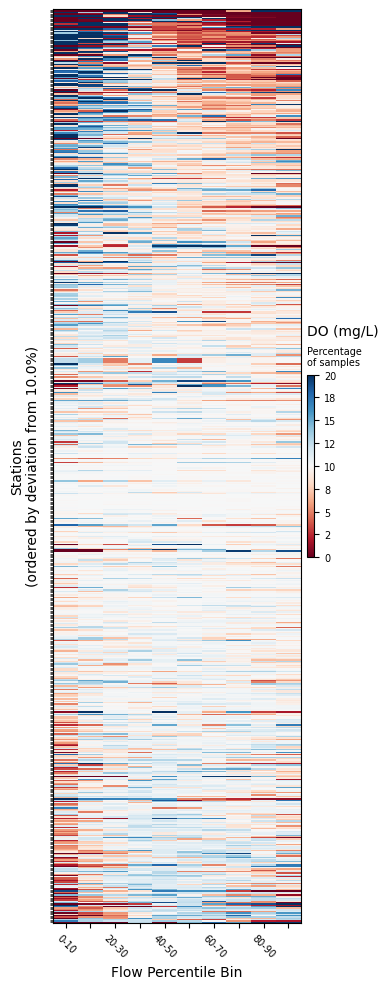

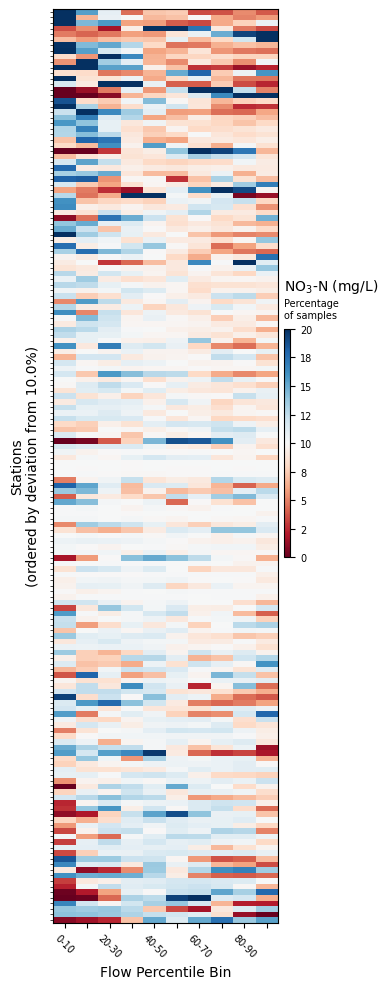

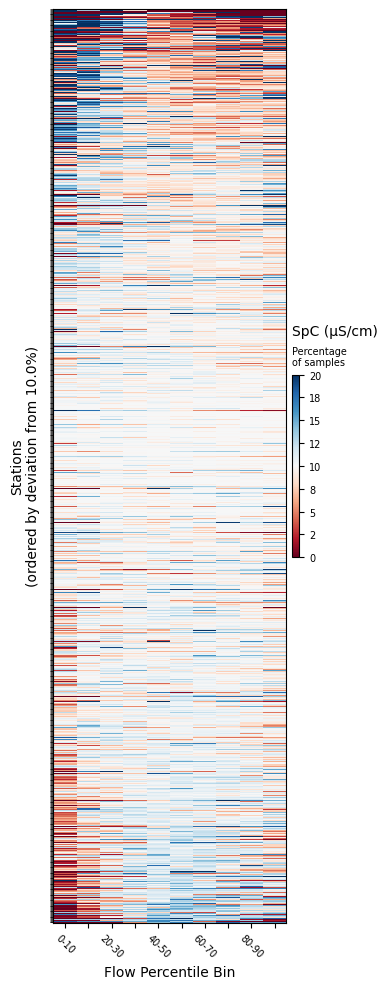

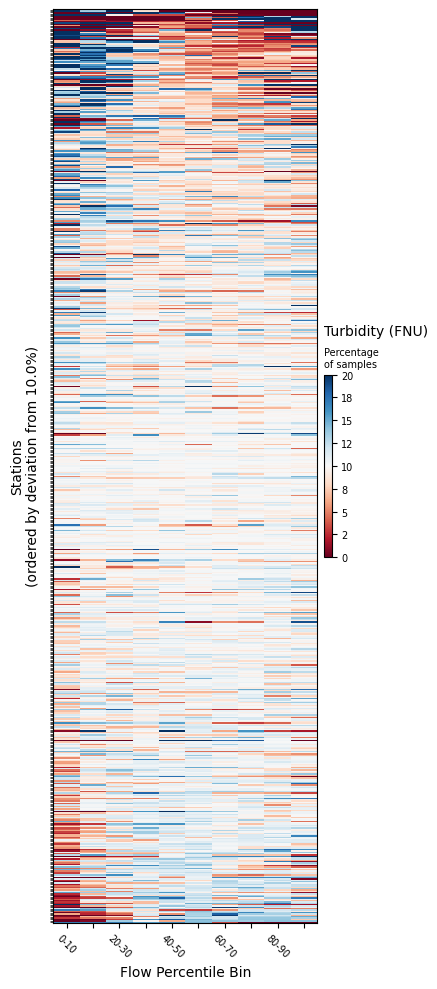

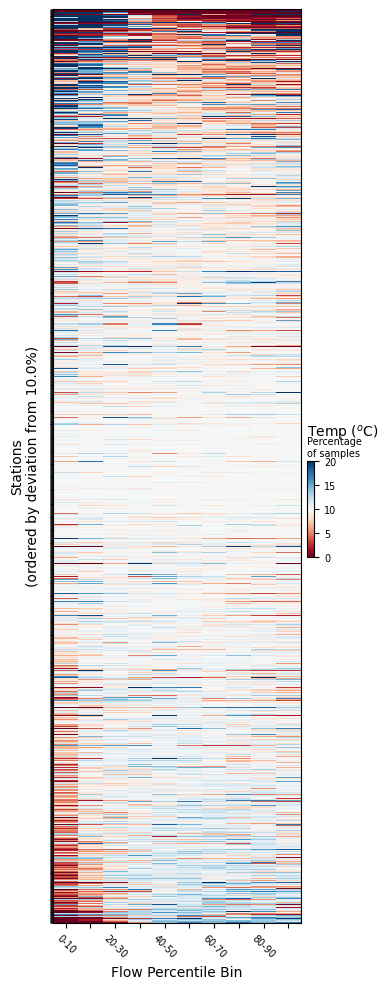

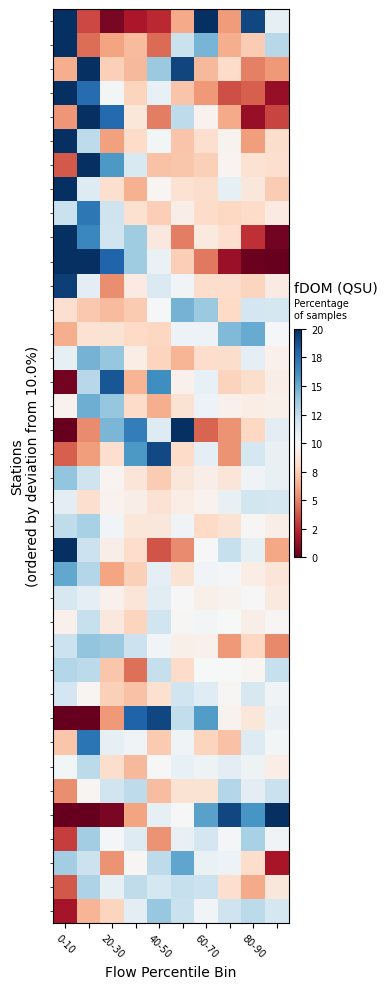

In [89]:
# Create heat map for each solute

solute_summary = []
#WQ_Q_binned_fractions_ss = WQ_Q_binned_fractions[WQ_Q_binned_fractions['param'].isin(params)]
for solute, binned_sol in WQ_Q_binned_fractions.groupby('param'):

    cfg = cbar_config.get(solute, default_cbar_config)
    
    # Currently sorted by STREAM ID (inherent). Uncomment to sort by high-flow sampling coverage.
    binned_sol = binned_sol.copy()
    binned_sol['sort_key'] = (binned_sol[bin_labels] - expected).abs().median(axis=1)
    binned_sol.sort_values('sort_key', ascending=False, inplace=True)
    binned_sol.drop(columns='sort_key', inplace=True)

    # bin bounds parsed once, so the summary tracks n_bins automatically
    lows  = np.array([int(l.split('-')[0]) for l in bin_labels])
    highs = np.array([int(l.split('-')[1]) for l in bin_labels])

    low_cols  = [l for l, hi in zip(bin_labels, highs) if hi <= 10]   # bottom 10% of flow
    high_cols = [l for l, lo in zip(bin_labels, lows)  if lo >= 90]   # top 10% of flow
    mid_cols  = [l for l, lo, hi in zip(bin_labels, lows, highs) if lo >= 25 and hi <= 75]

    solute_summary_i = {
        'solute': solute,
        'n_sites': len(binned_sol),
        'median_n_samples': binned_sol['n_samples'].median(),
        'pct_below_10p': binned_sol[low_cols].sum(axis=1).mean(),
        'pct_above_90p': binned_sol[high_cols].sum(axis=1).mean(),
        'mean_abs_deviation': (binned_sol[bin_labels] - expected * 100).abs().mean().mean(),
        'pct_sites_no_highflow': (binned_sol[high_cols].sum(axis=1) == 0).mean() * 100,
        'peak_bin': binned_sol[bin_labels].median().idxmax(),
        'pct_mid_flow': binned_sol[mid_cols].sum(axis=1).mean(),
    }
    solute_summary.append(solute_summary_i)
    
    # Extrating values
    plot_matrix = binned_sol[bin_labels].values
    site_labels = binned_sol['STREAM_ID'].values

    # Crating heatmap
    fig, ax = plt.subplots(figsize= (cfg['fig_width'], cfg['fig_height'])) #(4,10) max(3, len(site_labels) * 0.02)
    
    vmax = 20 # percent (cbar max range)
    norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=expected*100, vmax=vmax) # setting max, min, and zero place
    
    im = ax.pcolormesh(plot_matrix, cmap='RdBu', norm=norm, edgecolors='none')

    # x axis aesthethic properties
    ax.set_xticks(np.arange(n_bins) + 0.5)
    ax.set_xticklabels([label if i % 2 == 0 else '' for i, label in enumerate(bin_labels)],
                   rotation=360-45, ha='center', fontsize=7)
    ax.set_xlabel('Flow Percentile Bin')

    # y axis aesthethic properties
    ax.set_yticks(np.arange(len(site_labels)) + 0.5)
    ax.set_yticklabels([])
    ax.tick_params(axis='y', length=2, width=0.5)
    ax.set_ylabel(f'Stations\n(ordered by deviation from {round(expected*100,0)}%)')

    # color bar aesthethic properties
    cbax = ax.inset_axes(cfg['inset'], transform=ax.transAxes)
    cbar = fig.colorbar(im, cax=cbax, orientation='vertical')
    cbar.ax.tick_params(labelsize=7)

    tx, ty = cfg['title_xy']
    sx, sy = cfg['subtitle_xy']
    cbax.text(tx, ty, f'{solute_pretty[solute]}', fontsize=10,
              ha='left', va='bottom', transform=cbax.transAxes)
    cbax.text(sx, sy, 'Percentage\nof samples', fontsize=7,
              ha='left', va='bottom', transform=cbax.transAxes)
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
    
    plt.tight_layout()
    plt.savefig(f'../OUTPUT/temporal_patterns/sampling_bias_heatmap_{solute}.png', dpi=600, bbox_inches='tight')
    #plt.show()

In [ ]:
PARAM_COLORS = {
    'DO_mgL':    {'fill': '#FEDCBB', 'edge': '#7F2704'}, 
    'SpC_uScm':  {'fill': '#E2EDF8', 'edge': '#08306B'},
    'Turb_FNU':  {'fill': '#CEECC8', 'edge': '#00431A'},
    'WTemp_C':   {'fill': '#DADAEB', 'edge': '#3F007D'},  # Purples
    'NO3_mgNL':  {'fill': '#FEE0D2', 'edge': '#67000D'},  # Reds
    'fDOM_QSU':  {'fill': '#D9F0A3', 'edge': '#238443'},  # YlGn
}



In [90]:
import seaborn as sns
from matplotlib.lines import Line2D

params = list(PARAM_COLORS.keys())

long = (WQ_Q_binned_fractions[WQ_Q_binned_fractions['n_samples'] >= min_samples]
        .melt(id_vars=['STREAM_ID', 'param', 'n_samples'],
              value_vars=bin_labels, var_name='flow_bin', value_name='pct'))

fig, axes = plt.subplots(6, 1, figsize=(6, 12), sharex=True, sharey=True)

for ax, solute in zip(axes, params):
    g = long[long['param'] == solute]
    if g.empty:
        ax.set_visible(False)
        continue

    edge = PARAM_COLORS[solute]['edge']
    sns.boxplot(data=g, x='flow_bin', y='pct', order=bin_labels,
                color=PARAM_COLORS[solute]['fill'], showfliers=False, ax=ax,
                linewidth=0.8,
                boxprops=dict(edgecolor=edge),
                whiskerprops=dict(color=edge),
                capprops=dict(color=edge),
                medianprops=dict(color=edge, linewidth=1.4))

    # even-sampling reference, now clearly visible and on top of the boxes
    ax.axhline(expected * 100, ls='--', color='0.25', lw=1.1, zorder=5)

    # solute label on the left, outside the axes
    ax.annotate(f'{solute_pretty.get(solute, solute)}   (n = {g.STREAM_ID.nunique()})',
                xy=(1, 0.92), xycoords='axes fraction',
                ha='right', va='top', fontsize=9)

    ax.set_ylabel("% of samples", fontsize=8)
    ax.set_xlabel('')
    ax.tick_params(labelsize=7)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

# reference-line legend, top-left panel
axes[0].legend(handles=[Line2D([0], [0], ls='--', color='0.25', lw=1.1,
                               label=f'even sampling ({expected*100:.0f}%)')],
               frameon=False, fontsize=8, loc='upper left')

axes[-1].set_xlabel('Flow percentile bin')

ax = axes[-1]
ticks = range(0, len(bin_labels), 2)
ax.set_xticks(ticks)
ax.set_xticklabels([bin_labels[i] for i in ticks], rotation=0, ha='center', fontsize=7)

plt.tight_layout()
plt.subplots_adjust(hspace=0.15, left=0.15)
plt.savefig('../OUTPUT/temporal_patterns/sampling_bias_box_6panel.png',
            dpi=600, bbox_inches='tight')
plt.close(fig)

In [81]:
centers = np.array([(int(l.split('-')[0]) + int(l.split('-')[1])) / 2
                    for l in bin_labels])
exp_pct = expected * 100
color = '#3b6ea5'

params = params if 'params' in globals() else list(solute_pretty.keys())
params = params[:6]

fig, axes = plt.subplots(6, 1, figsize=(6, 14), sharex=True, sharey=True)

for ax, solute in zip(axes, params):
    g = WQ_Q_binned_fractions[(WQ_Q_binned_fractions['param'] == solute)
                              & (WQ_Q_binned_fractions['n_samples'] >= min_samples)]
    if g.empty:
        ax.set_visible(False)
        continue

    M = g[bin_labels].values                       # (n_sites, n_bins), already %
    med = np.median(M, axis=0)
    q25, q75 = np.percentile(M, [25, 75], axis=0)
    q10, q90 = np.percentile(M, [10, 90], axis=0)

    ax.fill_between(centers, q10, q90, color=color, alpha=0.15, lw=0)
    ax.fill_between(centers, q25, q75, color=color, alpha=0.30, lw=0)
    ax.plot(centers, med, color=color, lw=2.2)
    ax.axhline(exp_pct, ls='--', color='0.35', lw=1)

    ax.set_xlim(0, 100)
    ax.set_ylim([0,12])
    ax.set_ylabel("% of samples", fontsize=8)
    ax.annotate(f'{solute_pretty.get(solute, solute)}   (n = {M.shape[0]})',
                xy=(1, 0.1), xycoords='axes fraction', ha='right', va='top',
                fontsize=9)
    ax.tick_params(labelsize=7)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

axes[-1].set_xlabel('Flow percentile')

# one shared legend built from proxy handles, not per-panel labels
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color=color, lw=2.2, label='median site'),
    Patch(facecolor=color, alpha=0.30, label='25–75th pct of sites'),
    Patch(facecolor=color, alpha=0.15, label='10–90th pct of sites'),
    Line2D([0], [0], ls='--', color='0.35', lw=1,
           label=f'even sampling ({exp_pct:.0f}%)'),
]
axes[0].legend(handles=handles, frameon=False, fontsize=7, loc='upper right')

plt.tight_layout()
plt.subplots_adjust(hspace=0.12)
plt.savefig('../OUTPUT/temporal_patterns/sampling_bias_ribbon_6panel.png',
            dpi=600, bbox_inches='tight')
plt.close(fig)

In [91]:
# Process ChemLOTUS data
ChemLOTUS_df = pd.read_csv('C:/Users/danyk/Work/10_STREAM_data_gaps/INPUT/10_chemlotus/chemlotus_samples_discharge_antecedent.csv')

In [100]:
mask = ChemLOTUS_df['constituent'].isin(chem_solute)
ChemLOTUS_df = ChemLOTUS_df[mask]
ChemLOTUS_df.sort_values(by=['site_id', 'date'], inplace = True)
ChemLOTUS_df.head()


,site_id,comid,date,lat,lon,constituent,wq_value,streamflow_m3s,mean_q_1d,mean_q_3d,mean_q_7d,mean_q_14d,mean_q_30d,delta_q,delta_q_norm,day_of_year,TOT_BASIN_AREA
5454503,0801478-AR-1,916811,1991-04-30,39.248795,-106.348497,EC,233.799035,0.566337,0.566337,0.566337,0.574427,0.564314,0.564384,0.000000,0.000000,120,264.23
2248744,0801478-AR-1,916811,1991-04-30,39.248795,-106.348497,NO3,0.335780,0.566337,0.566337,0.566337,0.574427,0.564314,0.564384,0.000000,0.000000,120,264.23
5454502,0801478-AR-1,916811,1991-06-13,39.248795,-106.348497,EC,78.032141,11.553273,13.139017,11.562713,10.865579,9.399171,7.747099,-1.585745,-0.137255,164,264.23
2248746,0801478-AR-1,916811,1991-06-13,39.248795,-106.348497,NO3,0.018150,11.553273,13.139017,11.562713,10.865579,9.399171,7.747099,-1.585745,-0.137255,164,264.23
5454500,0801478-AR-1,916811,1991-07-25,39.248795,-106.348497,EC,110.458400,3.369705,2.860002,2.973269,2.742689,2.775051,3.527888,0.509703,0.151260,206,264.23


In [31]:
solute_summary_df = pd.DataFrame(solute_summary)
solute_summary_df.to_csv(OUTPUT_filepath+'discharge_statistics.csv', index=False)